In [49]:
import uproot
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
plt.style.use('belle2')
plt.rcParams['font.family'] = 'DejaVu Sans'

from sklearn.model_selection import train_test_split
import glob
import os

import joblib
from hep_ml import reweight

In [50]:
# Function to load and filter data from multiple files
def load_and_filter(file_paths, tree_name, cut_signal):
    branches = ['Pip_dr', 'Dp_dz', 'Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane', 'etapip_Eta_Easym', 'Dp_cosHelicityAngleMomentum', 'Dp_CMS_p', 'Pip_p', 'etapip_Eta_daughterDiffOfPhi_0_1', 'etapip_Eta_daughterAngle_0_1',
                'Pip_genMotherID', 'etapip_Eta_genMotherID',
                'Pip_genMotherPDG', 'etapip_Eta_isSignal','Dp_isSignal','Pip_pionID']
    
    if isinstance(file_paths, str):
        file_paths = glob.glob(file_paths)

    df_list = []
    for file_path in file_paths:
        try:
            df = uproot.open(file_path)[tree_name].arrays(branches, library="pd")
            df_filtered = df.query(cut_signal)
            df_list.append(df_filtered)
        except Exception as e:
            print(f"[Warning] Skipping file {file_path}: {e}")

    return pd.concat(df_list, ignore_index=True)

In [51]:
# Function to load and filter data from multiple files
def load_and_filter_ds_weight(file_paths, tree_name, cut_signal):
    branches = ['Pip_dr', 'Dp_dz', 'Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane', 'etapip_Eta_Easym', 'Dp_cosHelicityAngleMomentum', 'Dp_CMS_p',  'Pip_p', 'etapip_Eta_daughterDiffOfPhi_0_1', 'etapip_Eta_daughterAngle_0_1',
                'Pip_genMotherID', 'etapip_Eta_genMotherID',
                'Pip_genMotherPDG', 'etapip_Eta_isSignal', 'ds_weight', 'Dp_isSignal', 'Pip_pionID']
    
    if isinstance(file_paths, str):
        file_paths = glob.glob(file_paths)

    df_list = []
    for file_path in file_paths:
        try:
            df = uproot.open(file_path)[tree_name].arrays(branches, library="pd")
            df_filtered = df.query(cut_signal)
            df_list.append(df_filtered)
        except Exception as e:
            print(f"[Warning] Skipping file {file_path}: {e}")

    return pd.concat(df_list, ignore_index=True)

In [52]:
feature_labels = {
    'Pip_dr': r'$dr(\pi^+)$',
    'Dp_dz': r'$dz(D^+_{(s)})$',
    'Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane': r'$\cos \theta_{XY}$',
    'etapip_Eta_Easym': r'$|\frac{E_{\gamma_1} - E_{\gamma_2} }{E_{\gamma_1} + E_{\gamma_2}}|$',
    'Dp_cosHelicityAngleMomentum': r'cosHel$(D^+_{(s)})$',
    'Dp_CMS_p': r'$p^*(D^+_{(s)})$'
}

In [53]:
signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"

# cut_signal_pi = signal_cut_Dp_pi
# cut_signal_K = signal_cut_Dp_K


cut_signal_pi = "Dp_isSignal==1"
cut_signal_K = "Dp_isSignal==1"
cut_signal_pi += " & Pip_p>0.4 &  abs(etapip_Eta_daughterDiffOfPhi_0_1)<1.8 & etapip_Eta_daughterAngle_0_1<1.6"
cut_signal_K += " & Pip_p>0.4 &  abs(etapip_Eta_daughterDiffOfPhi_0_1)<1.8 & etapip_Eta_daughterAngle_0_1<1.6"
cut_signal_K += " & Pip_pionID < 0.01"

# cut_signal += ' & Dp_CMS_cosTheta > 0 '


# === Signal and Reference file patterns ===
signal_file = []
# signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_gg/250216_loose_v7/etapip_gg/ref/min_unc_search/new_Ds_v2/0.91/*BCS.root")
# signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_gg_cc/250216_loose_v7/etapip_gg/ref/min_unc_search/new_Ds_v2/0.91/*BCS.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_gg/250216_loose_v7/*.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_gg_cc/250216_loose_v7/*.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal_pi = load_and_filter(signal_pattern, "etapip_gg",cut_signal_pi)


signal_file_K = []
# signal_file_K.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_gg/250216_loose_v7/etapip_gg_K/min_unc_search/new_Ds_v2/0.91/*BCS.root")
# signal_file_K.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_gg_cc/250216_loose_v7/etapip_gg_K/min_unc_search/new_Ds_v2/0.91/*BCS.root")

signal_file_K.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_gg/250216_loose_v7/*.root")
signal_file_K.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_gg_cc/250216_loose_v7/*.root")
signal_pattern_K = []
for element in signal_file_K:
    signal_pattern_K += glob.glob(element)

# print(signal_pattern)
df_signal_K = load_and_filter(signal_pattern_K, "etapip_gg_K",cut_signal_K)



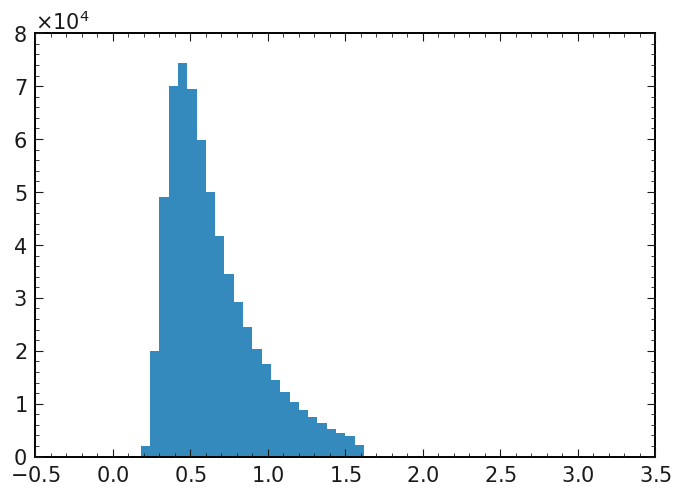

In [60]:
plt.hist(df_signal_K["etapip_Eta_daughterAngle_0_1"], bins=np.linspace(0,3,51));

In [61]:
# === Combine data and create labels ===
variables = ['Pip_dr', 'Dp_dz', 'Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane', 'etapip_Eta_Easym', 'Dp_cosHelicityAngleMomentum', 'Dp_CMS_p']

df_signal_pi['label'] = 0
df_signal_K['label'] = 1

In [62]:
# === Balance datasets ===
n_signal_pi = len(df_signal_pi)
n_signal_K = len(df_signal_K)

n_min = min(n_signal_pi, n_signal_K)

In [63]:
# Sample equal number of events from each
balanced_signal_pi = df_signal_pi.sample(n=n_min, random_state=42)
balanced_signal_K = df_signal_K.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal_pi, balanced_signal_K], ignore_index=True)


In [70]:
# === Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(
    combined_df[variables], combined_df['label'], test_size=0.3, random_state=42
)

# === Train XGBoost ===
model = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    subsample=0.6, use_label_encoder=False, eval_metric='logloss'
)
# model = xgb.XGBClassifier(
# use_label_encoder=False, eval_metric='logloss'
# )
model.fit(X_train, y_train)

# === Save model using joblib ===
joblib.dump(model, f"xgb_model_etapip_gg_K_etapip_gg.pkl")
print(f"✅ Model saved to 'xgb_model_etapip_gg_K_etapip_gg.pkl'")

# === Predict and reweight ===
proba_signal_pi = model.predict_proba(df_signal_pi[variables])[:, 1]
df_signal_pi['weight'] = proba_signal_pi / (1 - proba_signal_pi + 1e-6)

# Normalize to preserve total yield of original ds_weight
target_total = len(df_signal_pi)
actual_total = df_signal_pi['weight'].sum()
df_signal_pi['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_etapip_gg_K_etapip_gg.pkl'


In [71]:
mode = r"$D^+ \to \eta_{\gamma\gamma} K^+$"
ref_mode = r"$D^+ \to \eta_{\gamma\gamma} \pi^+$"
bins_dict = {
    'Pip_dr': np.linspace(0, 0.3, 51),
    'Dp_dz': np.linspace(-0.5, 0.5, 51),
    'Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane': np.linspace(-1, 1, 51),
    'etapip_Eta_Easym': np.linspace(0, 1, 51),
    'Dp_cosHelicityAngleMomentum': np.linspace(-1, 1, 51),
    'Dp_CMS_p': np.linspace(2.5, 5.5, 51)
}


legend_loc = {
    'Pip_dr': 'upper right',
    'Dp_dz': 'upper left',
    'Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane': 'upper left',
    'etapip_Eta_Easym': 'upper right',
    'Dp_cosHelicityAngleMomentum': 'upper right',
    'Dp_CMS_p': 'upper right'
}
var_info = feature_labels

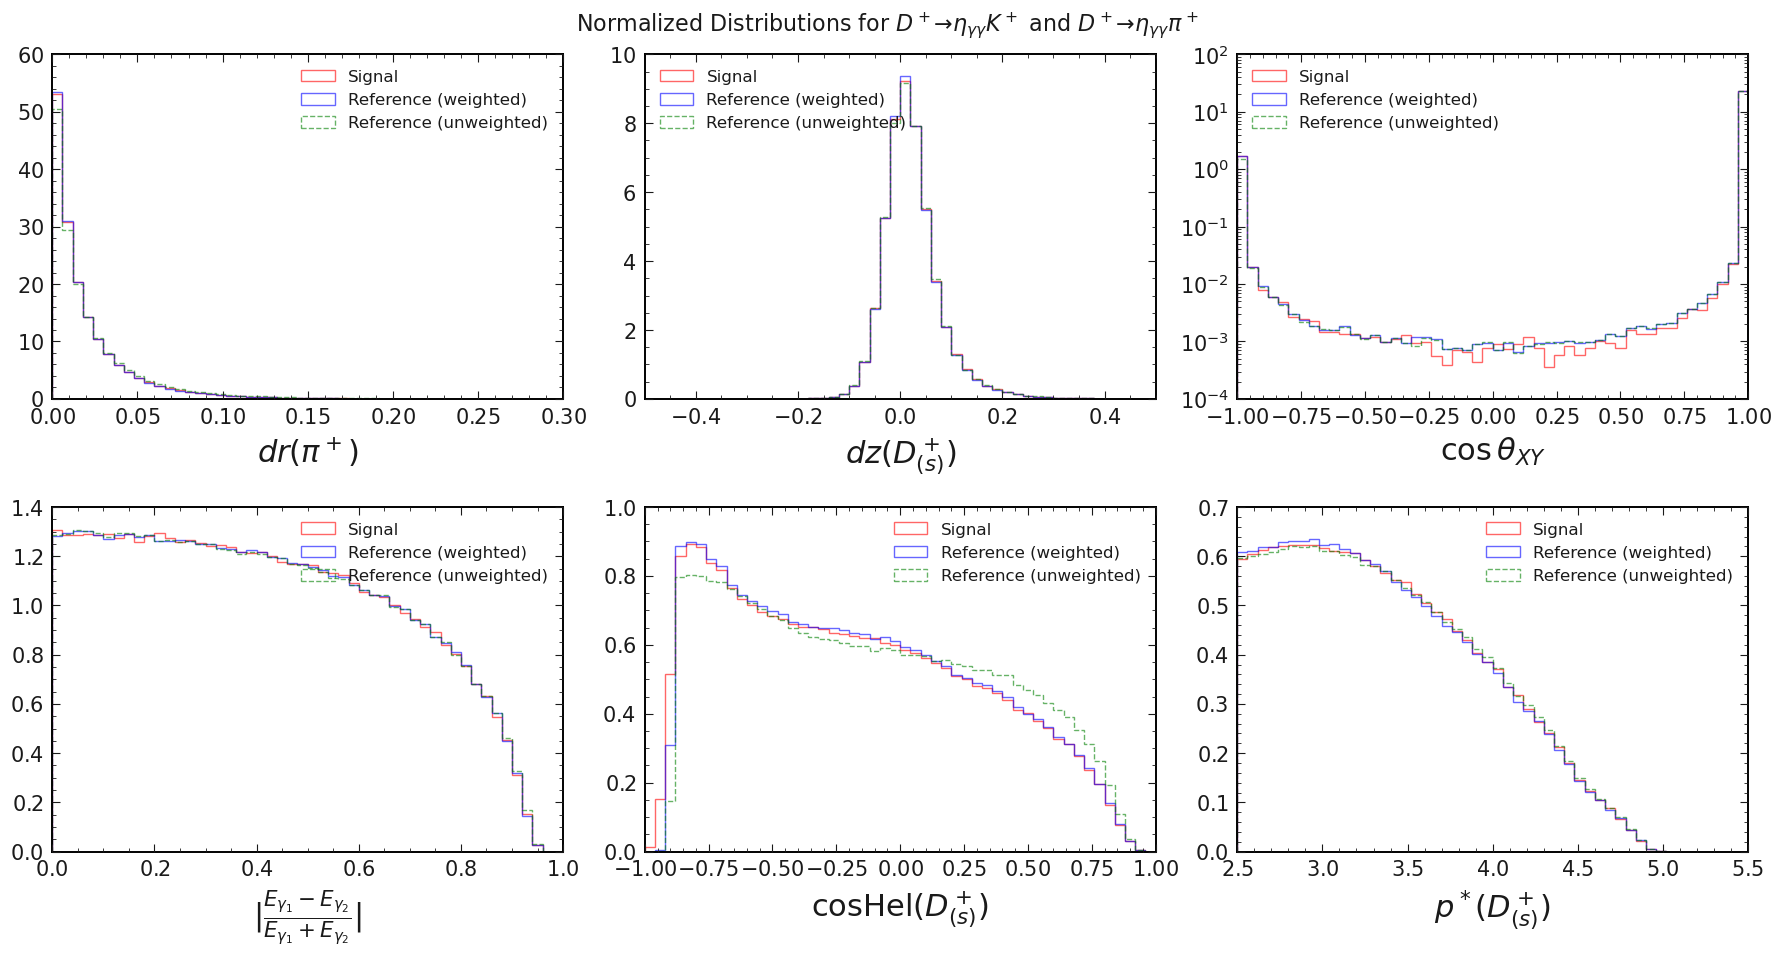

In [72]:
# === Plot distributions ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal_K[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Signal', color='red')
    axes[idx].hist(df_signal_pi[var], bins=bins, density=True, alpha=0.6, histtype='step', weights=df_signal_pi['weight'], label='Reference (weighted)', color='blue')
    axes[idx].hist(df_signal_pi[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Reference (unweighted)', linestyle='--', color='green')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var], fontsize=12)

    if var == 'Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane':
        axes[idx].set_yscale('log')

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode}', fontsize=16, y=0.96)
plt.tight_layout()
plt.savefig("etapip_gg_K_etapip_gg_reweighted.pdf")
plt.show()


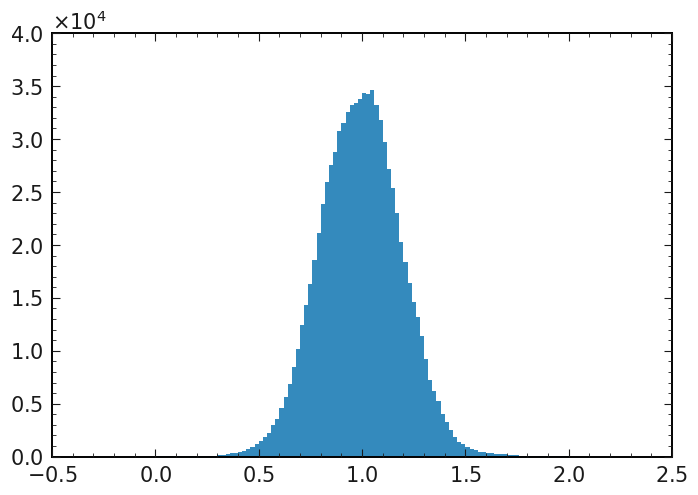

In [73]:
plt.hist(df_signal_pi['weight'], bins=np.linspace(0,2,101));

In [74]:
# === Prepare training data ===
variables = ['Pip_dr', 'Dp_dz', 'Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane',
             'etapip_Eta_Easym', 'Dp_cosHelicityAngleMomentum', 'Dp_CMS_p']

# "df_signal_K" = target distribution (signal)
# "df_signal_pi" = to be reweighted (reference)

# Fit reweighter
# reweighter = reweight.GBReweighter(n_estimators=200, learning_rate=0.1,
                                   # max_depth=6, min_samples_leaf=1000,
                                   # gb_args={'subsample': 0.8})
# reweighter = reweight.GBReweighter(
    # n_estimators=100, learning_rate=0.05, max_depth=4, min_samples_leaf=1000, gb_args={"subsample": 0.4}
# )
reweighter = reweight.GBReweighter(
    n_estimators=100, learning_rate=0.2, max_depth=4, min_samples_leaf=1000, gb_args={"subsample": 0.6}
)
reweighter.fit(original=df_signal_pi[variables],
               target=df_signal_K[variables])



GBReweighter(gb_args={'subsample': 0.6}, max_depth=4, min_samples_leaf=1000,
             n_estimators=100)

In [75]:
joblib.dump(reweighter, 'reweighter_model_etapip_gg_K_etapip_gg_reweighted_hepml_100_0.2_4_1000_0.6.pkl')
# reweighter_loaded = joblib.load('reweighter_model.pkl')


['reweighter_model_etapip_gg_K_etapip_gg_reweighted_hepml_100_0.2_4_1000_0.6.pkl']

In [18]:
# reweighter = joblib.load('reweighter_model_etapip_gg_K_etapip_gg_reweighted_hepml_100_0.2_4_1000_0.6.pkl')

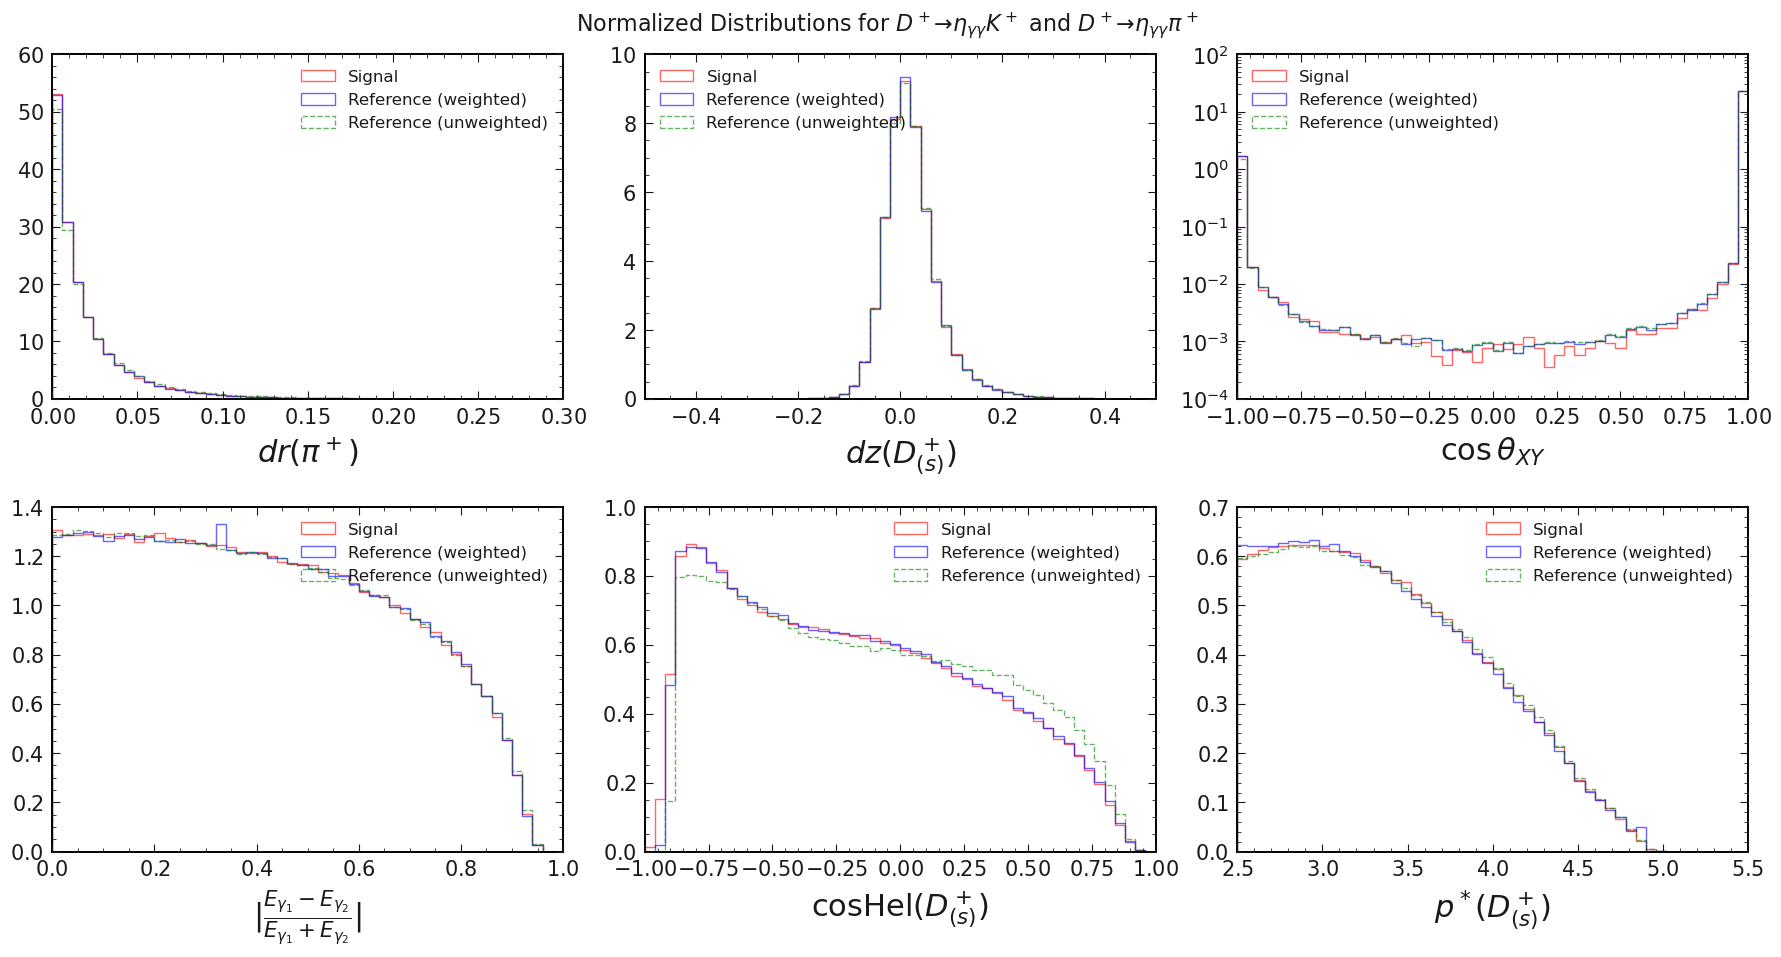

In [76]:
# Compute weights for reference sample
df_signal_pi['weight'] = reweighter.predict_weights(df_signal_pi[variables])

# Normalize weights to preserve total yield of df_signal_pi
df_signal_pi['weight'] *= len(df_signal_pi) / df_signal_pi['weight'].sum()

# === Plot distributions ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal_K[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', label='Signal', color='red')
    axes[idx].hist(df_signal_pi[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_signal_pi['weight'],
                   label='Reference (weighted)', color='blue')
    axes[idx].hist(df_signal_pi[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', label='Reference (unweighted)', linestyle='--',
                   color='green')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var], fontsize=12)

    if var == 'Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane':
        axes[idx].set_yscale('log')

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode}', fontsize=16, y=0.96)
plt.tight_layout()
# plt.savefig("etapip_gg_K_etapip_gg_reweighted_hepml.pdf")
plt.savefig("etapip_gg_K_etapip_gg_reweighted_hepml_100_0.2_4_1000_0.6.pdf")

plt.show()

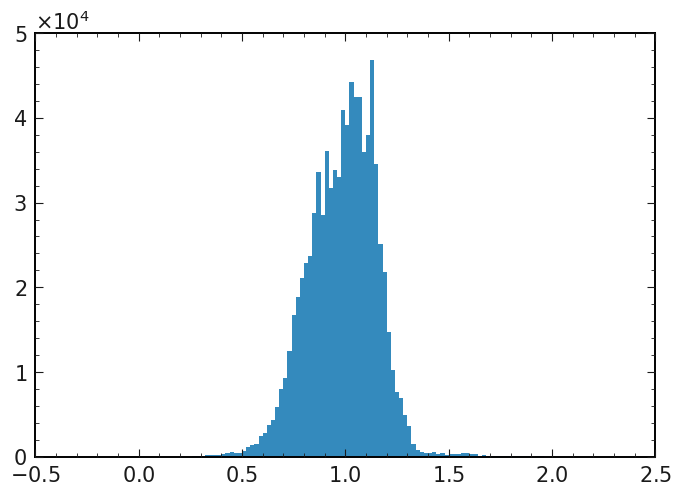

In [77]:
plt.hist(df_signal_pi['weight'], bins=np.linspace(0,2,101));

In [78]:
signal_cut_Dp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -211) )"
signal_cut_Dsp_pi = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 211) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -211) )"

signal_cut_Dp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 411 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -411 and Pip_mcPDG == -321) )"
signal_cut_Dsp_K = "(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )"

# cut_signal_pi = signal_cut_Dp_pi
# cut_signal_K = signal_cut_Dp_K


cut_signal_pi = "Dp_isSignal==1"
cut_signal_K = "Dp_isSignal==1"
cut_signal_pi += " & Pip_p>0.4 "
cut_signal_K += " & Pip_p>0.4 "
cut_signal_K += " & Pip_pionID < 0.01"

# cut_signal += ' & Dp_CMS_cosTheta > 0 '


# === Signal and Reference file patterns ===
signal_file = []
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_pipipi/250216_loose_v7/*.root")
signal_file.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/Dptoetapip_pipipi_cc/250216_loose_v7/*.root")
signal_pattern = []
for element in signal_file:
    signal_pattern += glob.glob(element)

# print(signal_pattern)
df_signal_pi = load_and_filter(signal_pattern, "etapip_pipipi",cut_signal_pi)


signal_file_K = []
signal_file_K.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_pipipi/250216_loose_v7/*.root")
signal_file_K.append("/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC/DptoetaKp_pipipi_cc/250216_loose_v7/*.root")
signal_pattern_K = []
for element in signal_file_K:
    signal_pattern_K += glob.glob(element)

# print(signal_pattern)
df_signal_K = load_and_filter(signal_pattern_K, "etapip_pipipi_K",cut_signal_K)



In [79]:
# === Combine data and create labels ===
variables = ['Pip_dr', 'Dp_dz', 'Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane', 'Dp_cosHelicityAngleMomentum', 'Dp_CMS_p']

df_signal_pi['label'] = 0
df_signal_K['label'] = 1

In [80]:
# === Balance datasets ===
n_signal_pi = len(df_signal_pi)
n_signal_K = len(df_signal_K)

n_min = min(n_signal_pi, n_signal_K)

In [81]:
# Sample equal number of events from each
balanced_signal_pi = df_signal_pi.sample(n=n_min, random_state=42)
balanced_signal_K = df_signal_K.sample(n=n_min, random_state=42)

combined_df = pd.concat([balanced_signal_pi, balanced_signal_K], ignore_index=True)


In [82]:
# === Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(
    combined_df[variables], combined_df['label'], test_size=0.3, random_state=42
)

# === Train XGBoost ===
model = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    subsample=0.6, use_label_encoder=False, eval_metric='logloss'
)
# model = xgb.XGBClassifier(
# use_label_encoder=False, eval_metric='logloss'
# )
model.fit(X_train, y_train)

# === Save model using joblib ===
joblib.dump(model, f"xgb_model_etapip_pipipi_K_etapip_pipipi.pkl")
print(f"✅ Model saved to 'xgb_model_etapip_pipipi_K_etapip_pipipi.pkl'")

# === Predict and reweight ===
proba_signal_pi = model.predict_proba(df_signal_pi[variables])[:, 1]
df_signal_pi['weight'] = proba_signal_pi / (1 - proba_signal_pi + 1e-6)

# Normalize to preserve total yield of original ds_weight
target_total = len(df_signal_pi)
actual_total = df_signal_pi['weight'].sum()
df_signal_pi['weight'] *= target_total / actual_total

/home/jykim/anaconda3/envs/draw/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


✅ Model saved to 'xgb_model_etapip_pipipi_K_etapip_pipipi.pkl'


In [83]:
mode = r"$D^+ \to \eta_{3\pi} K^+$"
ref_mode = r"$D^+ \to \eta_{3\pi} \pi^+$"
bins_dict = {
    'Pip_dr': np.linspace(0, 0.3, 51),
    'Dp_dz': np.linspace(-0.5, 0.5, 51),
    'Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane': np.linspace(-1, 1, 51),
    # 'etapip_Eta_Easym': np.linspace(0, 1, 51),
    'Dp_cosHelicityAngleMomentum': np.linspace(-1, 1, 51),
    'Dp_CMS_p': np.linspace(2.5, 5.5, 51)
}


legend_loc = {
    'Pip_dr': 'upper right',
    'Dp_dz': 'upper left',
    'Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane': 'upper left',
    # 'etapip_Eta_Easym': 'upper right',
    'Dp_cosHelicityAngleMomentum': 'upper right',
    'Dp_CMS_p': 'upper right'
}
var_info = feature_labels

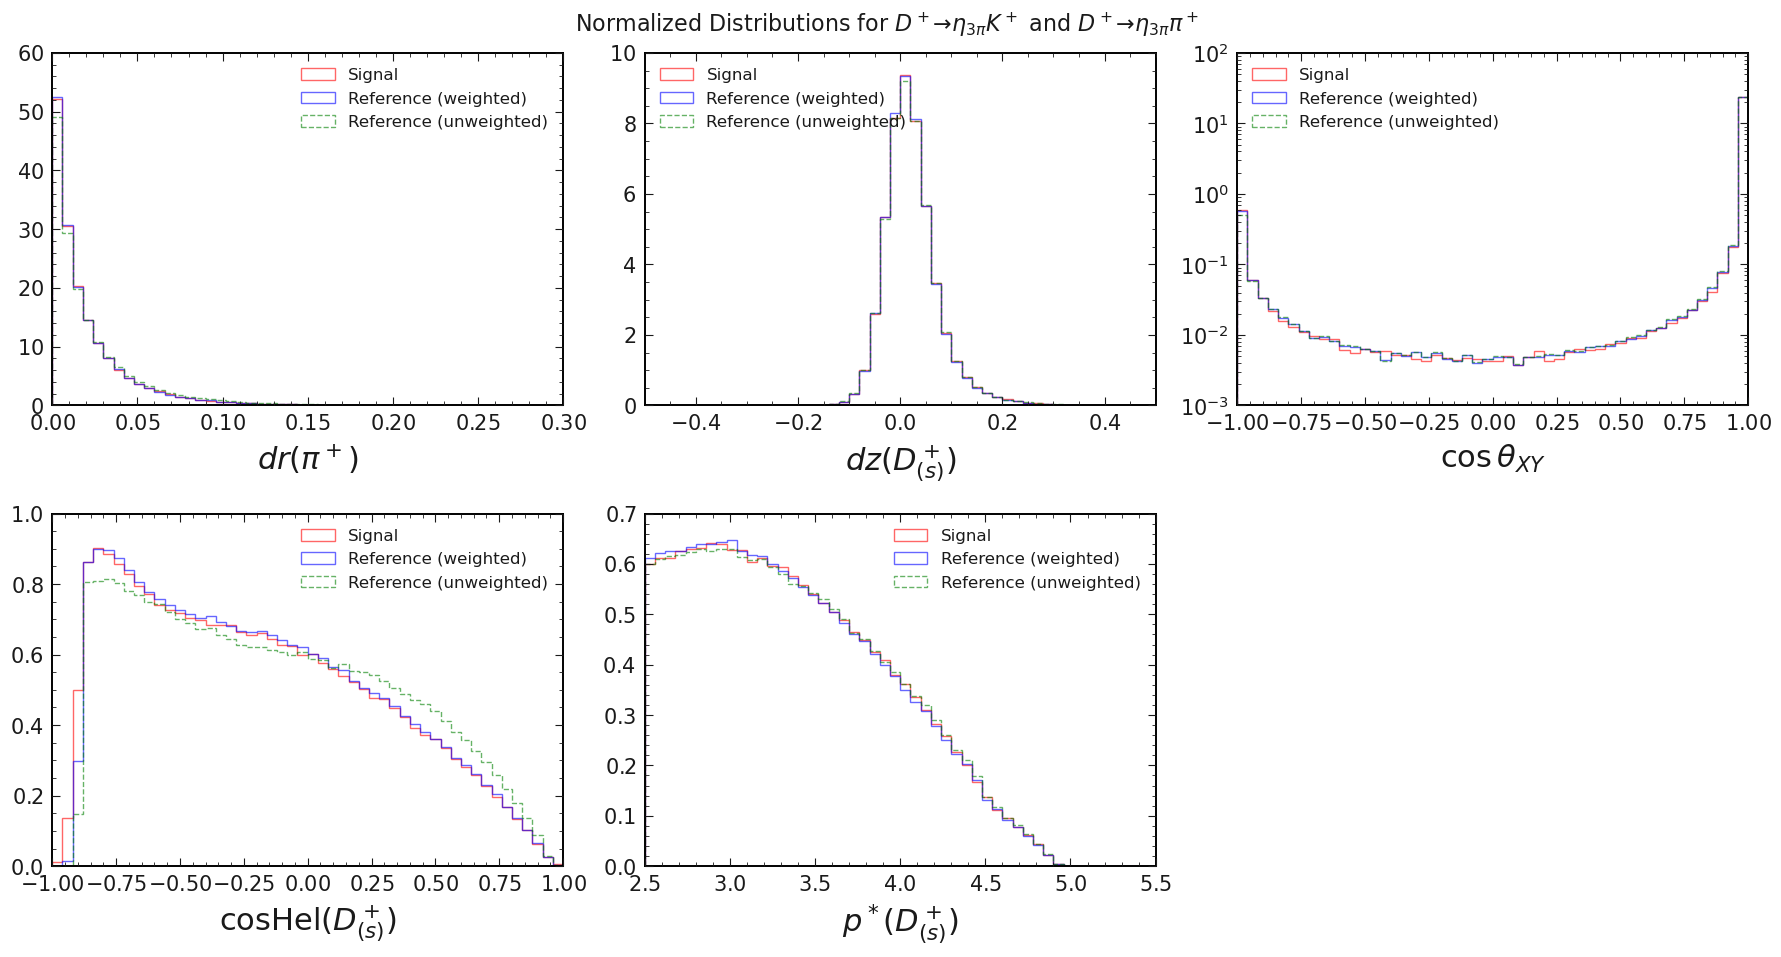

In [84]:
# === Plot distributions ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal_K[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Signal', color='red')
    axes[idx].hist(df_signal_pi[var], bins=bins, density=True, alpha=0.6, histtype='step', weights=df_signal_pi['weight'], label='Reference (weighted)', color='blue')
    axes[idx].hist(df_signal_pi[var], bins=bins, density=True, alpha=0.6, histtype='step', label='Reference (unweighted)', linestyle='--', color='green')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var], fontsize=12)

    if var == 'Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane':
        axes[idx].set_yscale('log')
        
if len(variables) < 6:
    axes[len(variables)].axis('off')
fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode}', fontsize=16, y=0.96)
plt.tight_layout()
plt.savefig("etapip_pipipi_K_etapip_pipipi_reweighted.pdf")
plt.show()


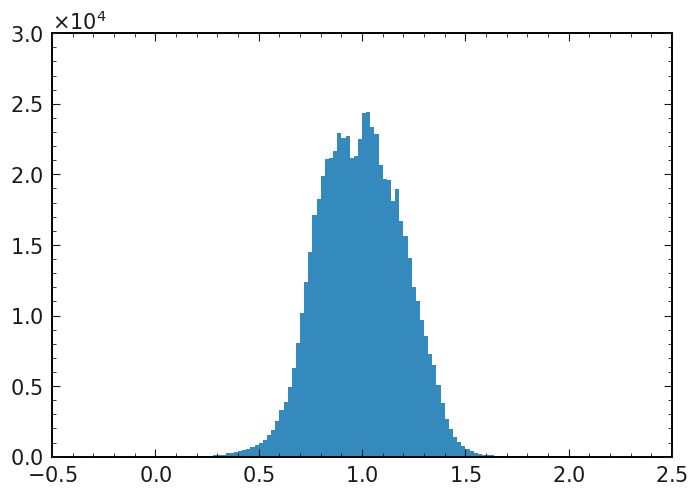

In [85]:
plt.hist(df_signal_pi['weight'], bins=np.linspace(0,2,101));

In [86]:
# === Prepare training data ===
variables = ['Pip_dr', 'Dp_dz', 'Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane',
             'Dp_cosHelicityAngleMomentum', 'Dp_CMS_p']

# "df_signal_K" = target distribution (signal)
# "df_signal_pi" = to be reweighted (reference)

# Fit reweighter
# reweighter = reweight.GBReweighter(n_estimators=200, learning_rate=0.1,
                                   # max_depth=6, min_samples_leaf=1000,
                                   # gb_args={'subsample': 0.8})
# reweighter = reweight.GBReweighter(
    # n_estimators=100, learning_rate=0.05, max_depth=4, min_samples_leaf=1000, gb_args={"subsample": 0.4}
# )
reweighter = reweight.GBReweighter(
    n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_leaf=1000, gb_args={"subsample": 0.6}
)
reweighter.fit(original=df_signal_pi[variables],
               target=df_signal_K[variables])



GBReweighter(gb_args={'subsample': 0.6}, learning_rate=0.1,
             min_samples_leaf=1000, n_estimators=100)

In [87]:
joblib.dump(reweighter, 'reweighter_model_etapip_pipipi_K_etapip_gg_reweighted_hepml_100_0.1_3_1000_0.6.pkl')
# reweighter_loaded = joblib.load('reweighter_model.pkl')


['reweighter_model_etapip_pipipi_K_etapip_gg_reweighted_hepml_100_0.1_3_1000_0.6.pkl']

In [88]:
# reweighter = joblib.load('reweighter_model_etapip_gg_K_etapip_gg_reweighted_hepml_100_0.2_4_1000_0.6.pkl')

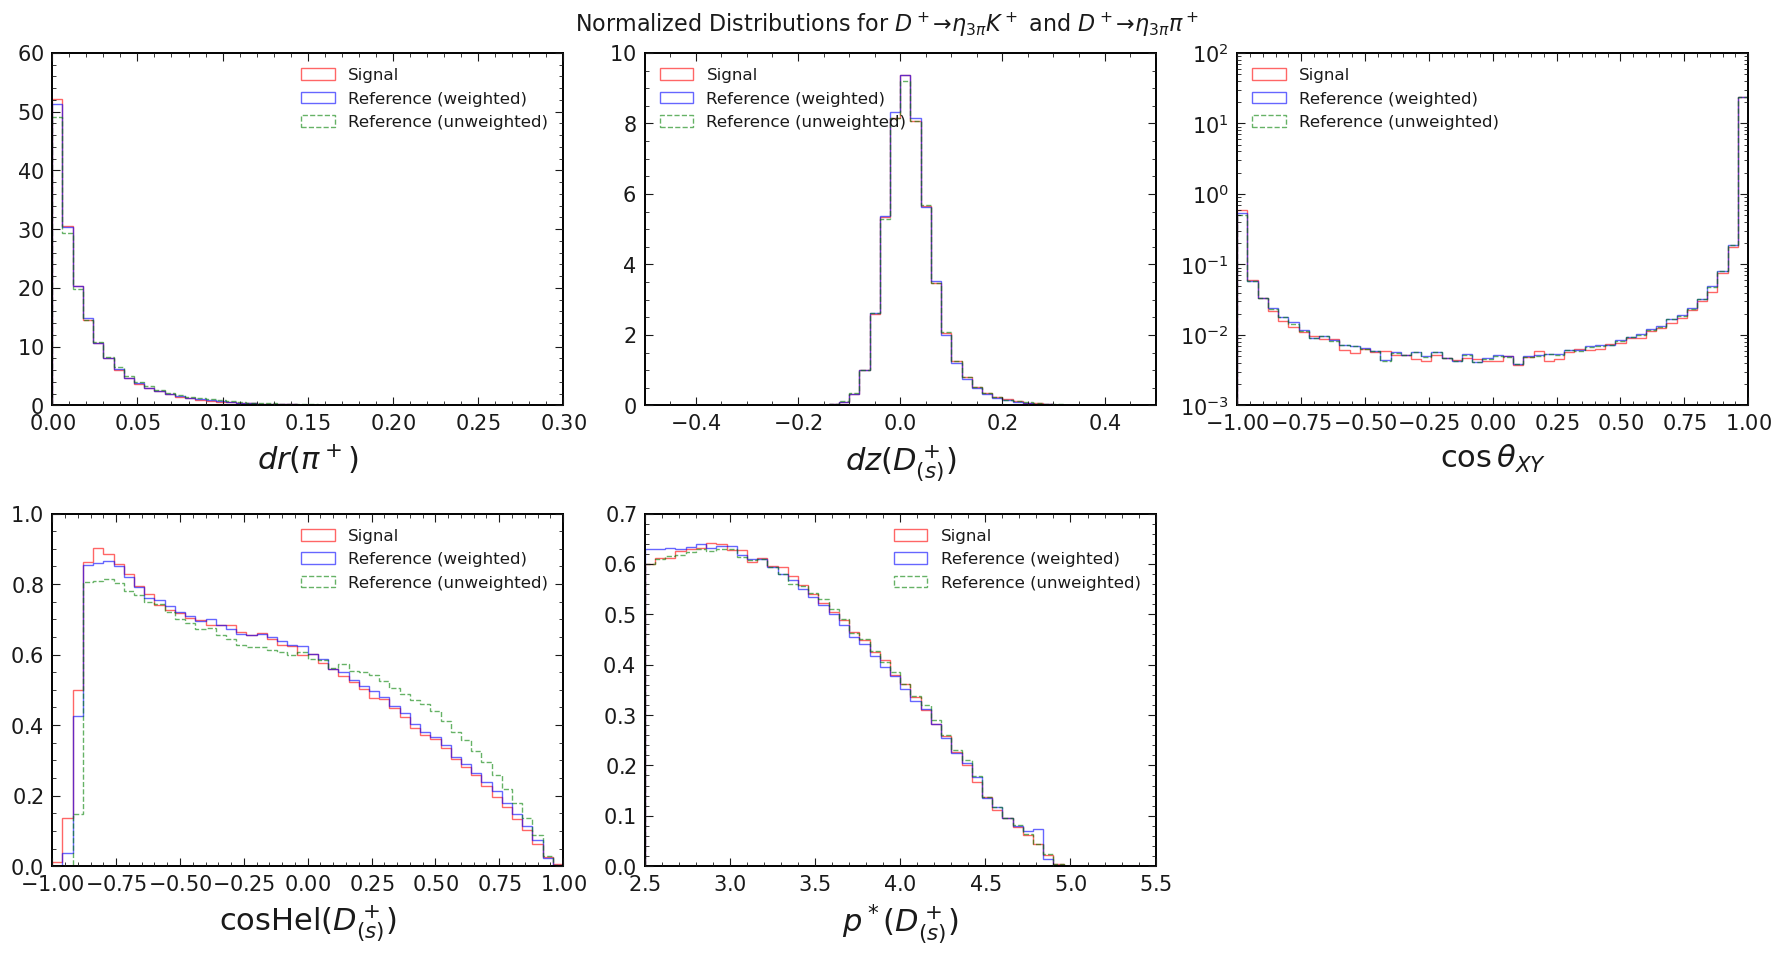

In [89]:
# Compute weights for reference sample
df_signal_pi['weight'] = reweighter.predict_weights(df_signal_pi[variables])

# Normalize weights to preserve total yield of df_signal_pi
df_signal_pi['weight'] *= len(df_signal_pi) / df_signal_pi['weight'].sum()

# === Plot distributions ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, var in enumerate(variables):
    bins = bins_dict[var]
    axes[idx].hist(df_signal_K[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', label='Signal', color='red')
    axes[idx].hist(df_signal_pi[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', weights=df_signal_pi['weight'],
                   label='Reference (weighted)', color='blue')
    axes[idx].hist(df_signal_pi[var], bins=bins, density=True, alpha=0.6,
                   histtype='step', label='Reference (unweighted)', linestyle='--',
                   color='green')
    axes[idx].set_xlim(bins[0], bins[-1])
    axes[idx].set_xlabel(f'{var_info[var]}')
    axes[idx].legend(loc=legend_loc[var], fontsize=12)

    if var == 'Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane':
        axes[idx].set_yscale('log')
if len(variables) < 6:
    axes[len(variables)].axis('off')

fig.suptitle(rf'Normalized Distributions for {mode} and {ref_mode}', fontsize=16, y=0.96)
plt.tight_layout()
# plt.savefig("etapip_gg_K_etapip_gg_reweighted_hepml.pdf")
plt.savefig("etapip_pipipi_K_etapip_pipipi_reweighted_hepml_100_0.1_3_1000_0.6.pdf")

plt.show()